# Data Analysis - Station Data

This notebook analyzes precipitation data from three sources:
1. **Ivoloina Station** - `DATA_station_Ivoloina_clean.csv`
2. **ASECNA Data** - `DONNEES 2014 2024_ASECNA.xlsx`
3. **Toamasina Station** - `Toamasina_2000_2024_cleaned.xlsx`

In [123]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import xarray as xr
warnings.filterwarnings('ignore')

# Set plotting style (matplotlib only, no seaborn)
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f0f0f0'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully!")

Libraries imported successfully!


# Precipitation

In [124]:
# Directories for data and output
data_dir = "/home/alice/Desktop/UniBo/data/obs_tamatave/"
MSWEP_dir = "/home/alice/Desktop/UniBo/data/MSWEP/MSWEP_V316_test/Past/Monthly/regridded_ERA5-Land/"
figure_dir = "/home/alice/Desktop/UniBo/figures/obs_tamatave/"

In [143]:
pos_toamasina = (-18.1, 49.3)  # Latitude, Longitude


## 1. Load and Inspect Ivoloina Station Data


In [158]:
# Load Ivoloina data
ivoloina = pd.read_csv(data_dir + 'DATA_station_Ivoloina_clean.csv', sep=';')

print("=== IVOLoina Station Data ===")
print(f"Shape: {ivoloina.shape}")
print(f"\nColumns: {list(ivoloina.columns)}")
print(f"\nData types:\n{ivoloina.dtypes}")
print(f"\nFirst 5 rows:\n{ivoloina.head()}")
print(f"\nMissing values:\n{ivoloina.isnull().sum()}")
print(f"\nDuplicated rows: {ivoloina.duplicated().sum()}")

=== IVOLoina Station Data ===
Shape: (46224, 14)

Columns: ['time', 'date', 'hour', 'T_air', 'relative_humidity', 'T_soil', 'solar_radiation', 'rain', 'wind_speed', 'rafale_speed', 'wind_direction', 'soil_moist', 'dew_point', 'battery']

Data types:
time                 object
date                 object
hour                 object
T_air                object
relative_humidity    object
T_soil               object
solar_radiation      object
rain                 object
wind_speed           object
rafale_speed         object
wind_direction       object
soil_moist           object
dew_point            object
battery              object
dtype: object

First 5 rows:
                  time        date                 hour   T_air  \
0  2024-12-18 08:50:00  2024-12-18  2024-12-18 08:50:00   31,95   
1  2024-12-18 09:00:00  2024-12-18  2024-12-18 09:00:00  31,242   
2  2024-12-18 09:10:00  2024-12-18  2024-12-18 09:10:00  31,027   
3  2024-12-18 09:20:00  2024-12-18  2024-12-18 09:20:00  31,2

In [159]:
# Ivoloina precipitation data
print("\n=== Ivoloina Precipitation Data ===")
# select column title "time" and "rain" side by side
print(ivoloina[['date', 'rain']])
# accumulate precipitation over each date
# Sum rain by date (daily precipitation totals)
daily_precip = ivoloina.groupby('date')['rain'].sum().reset_index()
daily_precip.columns = ['date', 'total_precipitation']

# Optional: sort by date
daily_precip = daily_precip.sort_values('date').reset_index(drop=True)

print(daily_precip["total_precipitation"])


=== Ivoloina Precipitation Data ===
             date rain
0      2024-12-18  NaN
1      2024-12-18    0
2      2024-12-18    0
3      2024-12-18    0
4      2024-12-18    0
...           ...  ...
46219  2026-03-24    0
46220  2026-03-24    0
46221  2026-03-24    0
46222  2026-03-24  0,2
46223  2026-03-24    0

[46224 rows x 2 columns]
0      0000000000000000000000000000000000000000000000...
1      0000000000000000000000000000000000000000000000...
2      0000000000000000000000000000000000000000000000...
3      0000000000000000000000000000000000000000,400,2...
4      000000000000000000000000,2000000000000000000,8...
                             ...                        
318    0000000000000000000000000000000000000000000000...
319    000000000000000000000000000000000000000001,200...
320    0000,400000000000,200,2000000,200000000,200000...
321    00000000000000000000000000000000001,41,4000000...
322    0000000000000000000000000000000000000000000000...
Name: total_precipitation, Length:

## 2. Load and Inspect ASECNA Data

In [160]:
# Load ASECNA data
asecna = pd.read_excel(data_dir + 'DONNEES 2014 2024_ASECNA_precipitation_mensuelle_mm.xlsx')

print("=== ASECNA Data ===")
print(f"Shape: {asecna.shape}")
print(f"\nColumns: {list(asecna.columns)}")
print(f"\nData types:\n{asecna.dtypes}")
print(f"\nFirst 5 rows:\n{asecna}")
print(f"\nMissing values:\n{asecna.isnull().sum()}")
print(f"\nDuplicated rows: {asecna.duplicated().sum()}")

=== ASECNA Data ===
Shape: (11, 13)

Columns: ['Unnamed: 0', 'JANV', 'FEV', 'MAR', 'AVR', 'MAI', 'JUIN', 'JUIL', 'AOUT', 'SEPT', 'OCT', 'NOV', 'DEC']

Data types:
Unnamed: 0    int64
JANV          int64
FEV           int64
MAR           int64
AVR           int64
MAI           int64
JUIN          int64
JUIL          int64
AOUT          int64
SEPT          int64
OCT           int64
NOV           int64
DEC           int64
dtype: object

First 5 rows:
    Unnamed: 0  JANV  FEV  MAR  AVR  MAI  JUIN  JUIL  AOUT  SEPT  OCT  NOV  \
0         2014   389  361  556  193  211   192   551   109   108   30  407   
1         2015   502  553  331   89  222   300   182   185   128  241   83   
2         2016   342  196  337  236  381   200   222   135    83   20   58   
3         2017   203  109  630  248  297   313   306   239    34  238  388   
4         2018   498  219  628  265  172   219   357    81    93   57  121   
5         2019   419  157  357  407  306   317   156    91   175   42  148   
6 

In [161]:
# climatology by month
monthly_precip_asecna = asecna.set_index(asecna.columns[0])

# Calculate climatology: mean for each month across all years
climatology_asecna = monthly_precip_asecna.mean()

# Result: array of 12 monthly values
print(climatology_asecna.values)
print(climatology_asecna)

[400.36363636 372.90909091 462.72727273 317.81818182 262.09090909
 229.63636364 265.90909091 168.72727273  97.81818182  97.
 142.63636364 208.        ]
JANV    400.363636
FEV     372.909091
MAR     462.727273
AVR     317.818182
MAI     262.090909
JUIN    229.636364
JUIL    265.909091
AOUT    168.727273
SEPT     97.818182
OCT      97.000000
NOV     142.636364
DEC     208.000000
dtype: float64


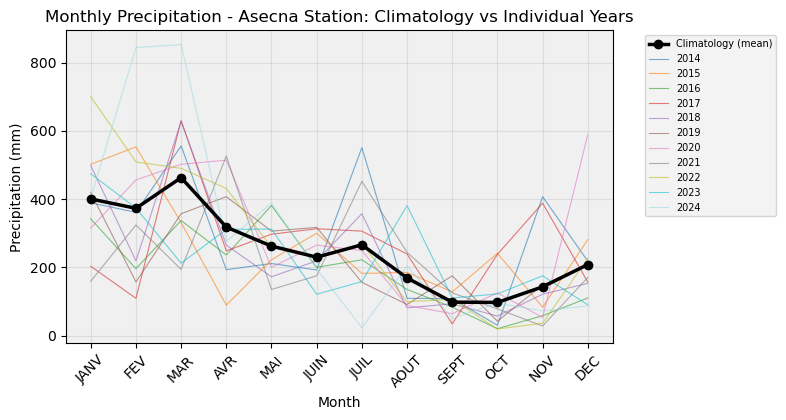

In [162]:
# Plot monthly climatology with individual years
plt.figure(figsize=(8, 4.3))

# Plot climatology (thick black line)
plt.plot(climatology_asecna.index, climatology_asecna.values, color='black', linewidth=2.5, marker='o', markersize=6, label='Climatology (mean)', zorder=10)

# Plot each year with different colors
colors = plt.cm.tab20(np.linspace(0, 1, len(monthly_precip_asecna.index)))
for i, (year, row) in enumerate(monthly_precip_asecna.iterrows()):
    plt.plot(row.index, row.values, color=colors[i], linewidth=0.8, alpha=0.6, label=str(year))

plt.title('Monthly Precipitation - Asecna Station: Climatology vs Individual Years')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Legend: climatology first, then years
handles, labels = plt.gca().get_legend_handles_labels()
# Move 'Climatology' to front
clim_idx = labels.index('Climatology (mean)')
handles = [handles[clim_idx]] + handles[:clim_idx] + handles[clim_idx+1:]
labels = [labels[clim_idx]] + labels[:clim_idx] + labels[clim_idx+1:]

plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_precipitation_Asecna.png', dpi=300)
plt.show()

## 3. Load and Inspect Toamasina Data

In [163]:
# Load Toamasina data
toamasina = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx')

print("=== Toamasina Station Data ===")
print(f"Shape: {toamasina.shape}")
print(f"\nColumns: {list(toamasina.columns)}")
print(f"\nData types:\n{toamasina.dtypes}")
print(f"\nFirst 5 rows:\n{toamasina.head()}")
print(f"\nMissing values:\n{toamasina.isnull().sum()}")
print(f"\nDuplicated rows: {toamasina.duplicated().sum()}")

=== Toamasina Station Data ===
Shape: (366, 11)

Columns: ['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

Data types:
date     object
tavg    float64
tmin    float64
tmax    float64
prcp    float64
snow    float64
wdir    float64
wspd    float64
wpgt    float64
pres    float64
tsun    float64
dtype: object

First 5 rows:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2024-01-01 00:00:00  27.9  25.0  31.0   7.8   NaN   NaN   9.4   NaN   
1  2024-01-02 00:00:00  29.7  24.2  37.2   0.0   NaN   NaN  13.3   NaN   
2  2024-01-03 00:00:00  29.4  25.3  37.2   0.3   NaN   NaN  14.1   NaN   
3  2024-01-04 00:00:00  29.0  26.8  33.0  11.7   NaN   NaN  12.7   NaN   
4  2024-01-05 00:00:00  27.9  24.4  32.7  46.0   NaN   NaN  13.4   NaN   

     pres  tsun  
0  1009.1   NaN  
1  1005.0   NaN  
2  1005.1   NaN  
3  1009.0   NaN  
4  1011.9   NaN  

Missing values:
date      0
tavg      0
tmin      1
tmax      1
prcp      4
snow 

In [164]:
# Read all sheets
all_sheets = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx', sheet_name=None)

# Merge all years into one dataframe
dfs = []
for year, df_year in all_sheets.items():
    df_year['year'] = int(year)
    if int(year) >=2021:
        dfs.append(df_year[['date','prcp']])

toamasina = pd.concat(dfs, ignore_index=True)

print(f"Shape: {toamasina.shape}")
print(f"Columns: {list(toamasina.columns)}")


Shape: (1461, 2)
Columns: ['date', 'prcp']


In [165]:
# Sum precipitation by month for Toamasina
toamasina['date'] = pd.to_datetime(toamasina['date'])
toamasina['year'] = toamasina['date'].dt.year
toamasina['month'] = toamasina['date'].dt.month
monthly_precip_toamasina = toamasina.groupby(['year', 'month'])['prcp'].sum().reset_index()
monthly_precip_toamasina.columns = ['year', 'month', 'total_precipitation']
print(monthly_precip_toamasina)

    year  month  total_precipitation
0   2021      1                206.7
1   2021      2                336.6
2   2021      3                302.1
3   2021      4                577.1
4   2021      5                157.4
5   2021      6                168.2
6   2021      7                410.7
7   2021      8                213.0
8   2021      9                144.8
9   2021     10                 73.5
10  2021     11                 70.3
11  2021     12                215.7
12  2022      1                832.0
13  2022      2                487.3
14  2022      3                427.4
15  2022      4                359.3
16  2022      5                248.1
17  2022      6                230.0
18  2022      7                257.2
19  2022      8                101.4
20  2022      9                107.9
21  2022     10                 34.6
22  2022     11                 90.1
23  2022     12                209.4
24  2023      1                534.2
25  2023      2                403.9
2

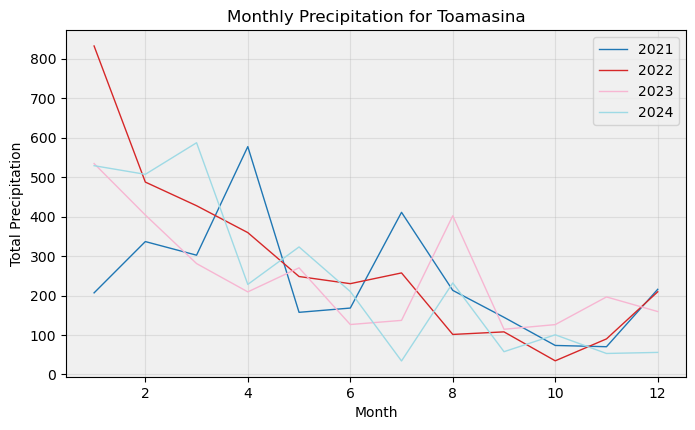

In [166]:
# Plot monthly precipitation for Toamasina, each year with different colors
plt.figure(figsize=(8, 4.5))
# Plot each year with different colors
colors = plt.cm.tab20(np.linspace(0, 1, monthly_precip_toamasina['year'].nunique()))
for i, (year, row) in enumerate(monthly_precip_toamasina.groupby('year')):
    plt.plot(row['month'], row['total_precipitation'], color=colors[i], linewidth=1, label=str(year))
plt.xlabel('Month')
plt.ylabel('Total Precipitation')
plt.title('Monthly Precipitation for Toamasina')
plt.legend()
plt.show()

## 4. Load MSWEP grid-point data

In [167]:
data_MSWEP = xr.load_dataset(MSWEP_dir + "precip_monthly_1993-2024_Madagascar.nc")
toamasina_MSWEP = data_MSWEP.sel(lat=pos_toamasina[0], lon=pos_toamasina[1], method='nearest')
toamasina_MSWEP_2021_2024 = toamasina_MSWEP.sel(time=slice('2021-01-01', '2024-12-31'))
toamasina_MSWEP_2014_2020 = toamasina_MSWEP.sel(time=slice('2014-01-01', '2020-12-31'))
climatology_MSWEP = toamasina_MSWEP_2014_2020.groupby('time.month').mean('time')


## 5. Comparison of time series

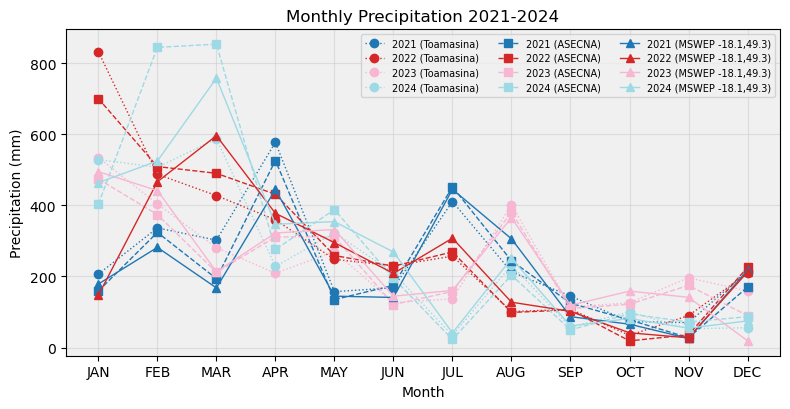

In [168]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))

colors = plt.cm.tab20(np.linspace(0, 1, monthly_precip_toamasina['year'].nunique()))
# Toamasina (numeric months 1-12)
for i, (year, row) in enumerate(monthly_precip_toamasina.groupby('year')):
    ax.plot(row['month'], row['total_precipitation'], color=colors[i], 
            linewidth=1, linestyle=':', marker='o', label=f'{year} (Toamasina)')

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_precip_asecna.loc[2021:2024].iterrows()):
    months_numeric = [month_map[m] for m in row.index]
    ax.plot(months_numeric, row.values, color=colors[i], 
            linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_MSWEP_2021_2024.groupby('time.year')):
    months_numeric = row['time.month'].values
    ax.plot(months_numeric, row['precipitation'].values, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Precipitation 2021-2024')
ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_precipitation_2021_2024_Toamasina_Asecna_MSWEP.png', dpi=300)
plt.show()


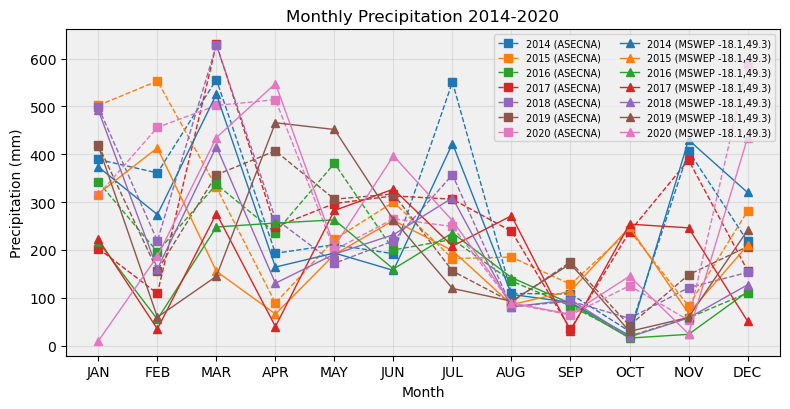

In [169]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = plt.cm.tab20(np.linspace(0, 1, 11))

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_precip_asecna.loc[2014:2020].iterrows()):
    months_numeric = [month_map[m] for m in row.index]
    ax.plot(months_numeric, row.values, color=colors[i], 
            linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_MSWEP_2014_2020.groupby('time.year')):
    months_numeric = row['time.month'].values
    ax.plot(months_numeric, row['precipitation'].values, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Precipitation 2014-2020')
ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_precipitation_2014_2020_Asecna_MSWEP.png', dpi=300)
plt.show()


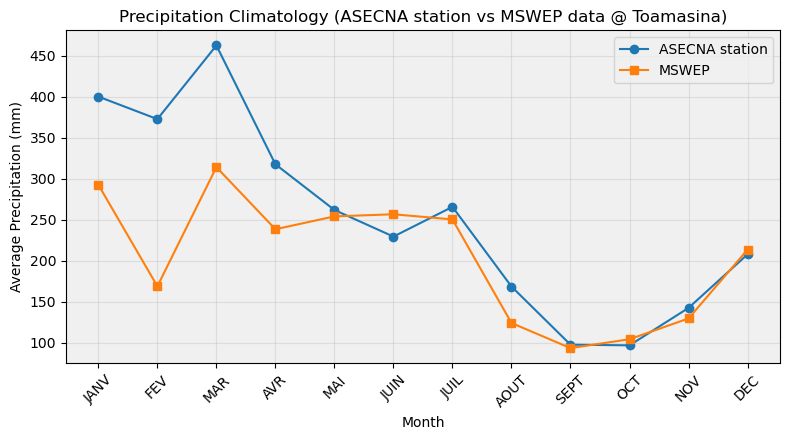

In [157]:
# Plot monthly climatology
plt.figure(figsize=(8, 4.5))
plt.plot(climatology_asecna.index, climatology_asecna.values, marker='o', label='ASECNA station')
plt.plot(climatology_MSWEP['month']-1, climatology_MSWEP['precipitation'], marker='s', label='MSWEP')
plt.title('Precipitation Climatology (ASECNA station vs MSWEP data @ Toamasina)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper right', fontsize=10, ncol=1)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_precipitation_climatology_2014_2024_ASECNA_MSWEP.png', dpi=300)#

# Temperature

In [ ]:
# Directories for data and output
data_dir = "/home/alice/Desktop/UniBo/data/obs_tamatave/"
ERA_dir = "/home/alice/Desktop/UniBo/data/ERA5-Land/t2m/monthly/"
figure_dir = "/home/alice/Desktop/UniBo/figures/obs_tamatave/"

In [48]:
pos_toamasina = (-18.1, 49.3)  # Latitude, Longitude
# lon is 49.3 instead of 49.4 to match the ERA5-Land grid point on land (49.4 is in the ocean, hence nan values for t2m)

## 1. Load and Inspect ASECNA Data

In [49]:
# Load ASECNA data
asecna_max = pd.read_excel(data_dir + 'DONNEES 2014 2024_ASECNA_temperature_max_mensuelle_C.xlsx')

print("=== ASECNA Data ===")
print(f"Shape: {asecna_max.shape}")
print(f"\nColumns: {list(asecna_max.columns)}")
print(f"\nData types:\n{asecna_max.dtypes}")
print(f"\nFirst 5 rows:\n{asecna_max}")
print(f"\nMissing values:\n{asecna_max.isnull().sum()}")
print(f"\nDuplicated rows: {asecna_max.duplicated().sum()}")

=== ASECNA Data ===
Shape: (11, 13)

Columns: ['Unnamed: 0', 'JANV', 'FEV', ' MAR', 'AVR', 'MAI', 'JUIN', 'JUIL', 'AOUT', 'SEPT', 'OCT', 'NOV', 'DEC']

Data types:
Unnamed: 0      int64
JANV          float64
FEV           float64
 MAR          float64
AVR           float64
MAI           float64
JUIN          float64
JUIL          float64
AOUT          float64
SEPT          float64
OCT           float64
NOV           float64
DEC           float64
dtype: object

First 5 rows:
    Unnamed: 0  JANV   FEV   MAR   AVR   MAI  JUIN  JUIL  AOUT  SEPT   OCT  \
0         2014  30.9  30.9  31.2  29.8  28.4  26.8  25.4  26.2  27.0  28.8   
1         2015  32.1  30.4  30.5  30.6  29.1  27.0  26.3  26.1  26.7  28.0   
2         2016  31.6  31.7  31.5  30.6  26.8  25.9  25.4  26.3  26.3  28.3   
3         2017  30.9  31.9  30.9  30.4  28.6  27.4  26.3  26.1  27.8  28.9   
4         2018  30.8  31.4  30.2  29.5  28.4  27.0  24.9  27.0  27.4  28.0   
5         2019  31.3  31.4  31.5  31.1  28.5  26.5  2

In [50]:
asecna_min = pd.read_excel(data_dir + 'DONNEES 2014 2024_ASECNA_temperature_min_mensuelle_C.xlsx')

print("=== ASECNA Data ===")
print(f"Shape: {asecna_min.shape}")
print(f"\nColumns: {list(asecna_min.columns)}")
print(f"\nData types:\n{asecna_min.dtypes}")
print(f"\nFirst 5 rows:\n{asecna_min}")
print(f"\nMissing values:\n{asecna_min.isnull().sum()}")
print(f"\nDuplicated rows: {asecna_min.duplicated().sum()}")

=== ASECNA Data ===
Shape: (11, 13)

Columns: ['Unnamed: 0', 'JANV', 'FEV', ' MAR', 'AVR', 'MAI', 'JUIN', 'JUIL', 'AOUT', 'SEPT', 'OCT', 'NOV', 'DEC']

Data types:
Unnamed: 0      int64
JANV          float64
FEV           float64
 MAR          float64
AVR           float64
MAI           float64
JUIN          float64
JUIL          float64
AOUT          float64
SEPT          float64
OCT           float64
NOV           float64
DEC           float64
dtype: object

First 5 rows:
    Unnamed: 0  JANV   FEV   MAR   AVR   MAI  JUIN  JUIL  AOUT  SEPT   OCT  \
0         2014  22.9  22.6  22.7  21.4  19.9  18.6  18.3  18.0  17.9  21.4   
1         2015  23.7  23.2  22.8  22.0  20.9  19.6  18.1  17.5  18.1  20.0   
2         2016  23.4  23.8  23.8  22.3  19.5  18.6  17.4  17.5  18.3  20.0   
3         2017  22.8  23.1  23.9  22.8  20.9  19.2  17.9  18.3  19.0  20.6   
4         2018  22.8  22.6  22.3   NaN  21.3  19.1  17.8  18.4  18.4  20.0   
5         2019  23.9  23.3  23.5  23.3  20.9  19.5  1

In [51]:
# climatology by month
monthly_maxT_asecna = asecna_max.set_index(asecna_max.columns[0])
monthly_minT_asecna = asecna_min.set_index(asecna_min.columns[0])

# Calculate climatology: mean for each month across all years
climatology_maxT_asecna = monthly_maxT_asecna.mean()
climatology_minT_asecna = monthly_minT_asecna.mean()

# Result: array of 12 monthly values
print(climatology_maxT_asecna)
print(climatology_minT_asecna)

JANV    31.245455
FEV     31.181818
 MAR    30.890909
AVR     30.072727
MAI     28.318182
JUIN    26.563636
JUIL    25.790909
AOUT    26.327273
SEPT    27.072727
OCT     28.427273
NOV     29.754545
DEC     31.072727
dtype: float64
JANV    23.281818
FEV     23.236364
 MAR    23.263636
AVR     22.380000
MAI     20.518182
JUIN    18.863636
JUIL    17.918182
AOUT    17.727273
SEPT    18.263636
OCT     20.145455
NOV     21.363636
DEC     22.881818
dtype: float64


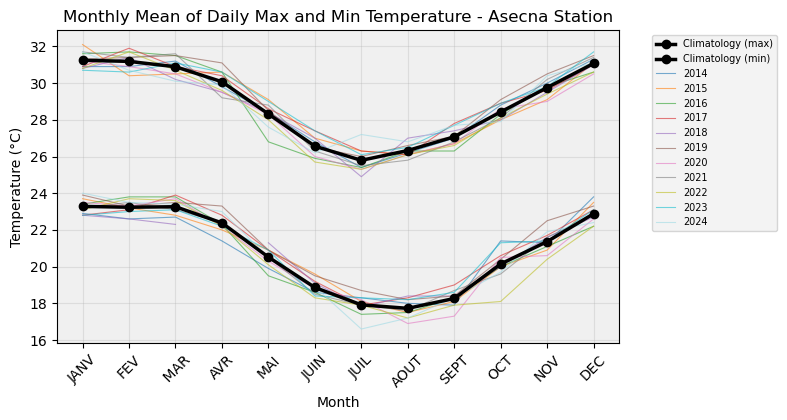

In [ ]:
# Plot monthly climatology with individual years
plt.figure(figsize=(8, 4.3))

# Plot climatology (thick black line)
plt.plot(climatology_maxT_asecna.index, climatology_maxT_asecna.values, color='black', linewidth=2.5, marker='o', markersize=6, label='Climatology (max)', zorder=10)
plt.plot(climatology_minT_asecna.index, climatology_minT_asecna.values, color='black', linewidth=2.5, marker='o', markersize=6, label='Climatology (min)', zorder=10)
    
# Plot each year with different colors
colors = plt.cm.tab20(np.linspace(0, 1, len(monthly_maxT_asecna.index)))
for i, (year, row) in enumerate(monthly_maxT_asecna.iterrows()):
    plt.plot(row.index, row.values, color=colors[i], linewidth=0.8, alpha=0.6, label=str(year))
for i, (year, row) in enumerate(monthly_minT_asecna.iterrows()):
    plt.plot(row.index, row.values, color=colors[i], linewidth=0.8, alpha=0.6)

plt.title('Monthly Mean of Daily Max and Min Temperature - Asecna Station')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Legend: climatology first, then years
handles, labels = plt.gca().get_legend_handles_labels()
# Move 'Climatology' to front
clim_idx = labels.index('Climatology (max)')
handles = [handles[clim_idx]] + handles[:clim_idx] + handles[clim_idx+1:]
labels = [labels[clim_idx]] + labels[:clim_idx] + labels[clim_idx+1:]

plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_maxT_minT_Asecna.png', dpi=300)
plt.show()

## 2. Load and Inspect Toamasina Data

In [53]:
# Load Toamasina data
toamasina = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx')

print("=== Toamasina Station Data ===")
print(f"Shape: {toamasina.shape}")
print(f"\nColumns: {list(toamasina.columns)}")
print(f"\nData types:\n{toamasina.dtypes}")
print(f"\nFirst 5 rows:\n{toamasina.head()}")
print(f"\nMissing values:\n{toamasina.isnull().sum()}")
print(f"\nDuplicated rows: {toamasina.duplicated().sum()}")

=== Toamasina Station Data ===
Shape: (366, 11)

Columns: ['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']

Data types:
date     object
tavg    float64
tmin    float64
tmax    float64
prcp    float64
snow    float64
wdir    float64
wspd    float64
wpgt    float64
pres    float64
tsun    float64
dtype: object

First 5 rows:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2024-01-01 00:00:00  27.9  25.0  31.0   7.8   NaN   NaN   9.4   NaN   
1  2024-01-02 00:00:00  29.7  24.2  37.2   0.0   NaN   NaN  13.3   NaN   
2  2024-01-03 00:00:00  29.4  25.3  37.2   0.3   NaN   NaN  14.1   NaN   
3  2024-01-04 00:00:00  29.0  26.8  33.0  11.7   NaN   NaN  12.7   NaN   
4  2024-01-05 00:00:00  27.9  24.4  32.7  46.0   NaN   NaN  13.4   NaN   

     pres  tsun  
0  1009.1   NaN  
1  1005.0   NaN  
2  1005.1   NaN  
3  1009.0   NaN  
4  1011.9   NaN  

Missing values:
date      0
tavg      0
tmin      1
tmax      1
prcp      4
snow 

In [54]:
# Read all sheets
all_sheets = pd.read_excel(data_dir + 'Toamasina_2000_2024_cleaned.xlsx', sheet_name=None)

# Merge all years into one dataframe
dfs = []
for year, df_year in all_sheets.items():
    df_year['year'] = int(year)
    if int(year) >=2021:
        dfs.append(df_year[['date','tmin','tmax']])

toamasina = pd.concat(dfs, ignore_index=True)

print(f"Shape: {toamasina.shape}")
print(f"Columns: {list(toamasina.columns)}")


Shape: (1461, 3)
Columns: ['date', 'tmin', 'tmax']


In [ ]:
# Sum precipitation by month for Toamasina
toamasina['date'] = pd.to_datetime(toamasina['date'])
toamasina['year'] = toamasina['date'].dt.year
toamasina['month'] = toamasina['date'].dt.month
monthly_tmin_toamasina = toamasina.groupby(['year', 'month'])['tmin'].mean().reset_index()
monthly_tmax_toamasina = toamasina.groupby(['year', 'month'])['tmax'].mean().reset_index()
print(monthly_tmin_toamasina)
print(monthly_tmax_toamasina)


    year  month       tmin
0   2021      1  23.190323
1   2021      2  23.550000
2   2021      3  23.103226
3   2021      4  22.390000
4   2021      5  20.374194
5   2021      6  18.406667
6   2021      7  17.883871
7   2021      8  17.645161
8   2021      9  18.530000
9   2021     10  19.354839
10  2021     11  21.416667
11  2021     12  22.793548
12  2022      1  23.080645
13  2022      2  23.767857
14  2022      3  23.551613
15  2022      4  22.150000
16  2022      5  19.990323
17  2022      6  18.360000
18  2022      7  17.880645
19  2022      8  17.180645
20  2022      9  17.916667
21  2022     10  17.870968
22  2022     11  20.343333
23  2022     12  22.174194
24  2023      1  22.829032
25  2023      2  22.982143
26  2023      3  23.077419
27  2023      4  22.363333
28  2023      5  20.861290
29  2023      6  18.540000
30  2023      7  18.187097
31  2023      8  18.038710
32  2023      9  18.646667
33  2023     10  21.193548
34  2023     11  21.416667
35  2023     12  23.051613
3

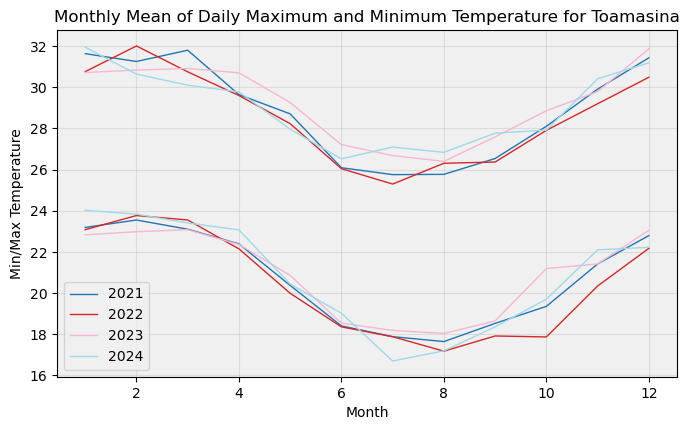

In [56]:
# Plot monthly precipitation for Toamasina, each year with different colors
plt.figure(figsize=(8, 4.5))
# Plot each year with different colors
colors = plt.cm.tab20(np.linspace(0, 1, monthly_tmin_toamasina['year'].nunique()))
for i, (year, row) in enumerate(monthly_tmin_toamasina.groupby('year')):
    plt.plot(row['month'], row['tmin'], color=colors[i], linewidth=1, label=str(year))
for i, (year, row) in enumerate(monthly_tmax_toamasina.groupby('year')):
    plt.plot(row['month'], row['tmax'], color=colors[i], linewidth=1)
plt.xlabel('Month')
plt.ylabel('Min/Max Temperature')
plt.title('Monthly Mean of Daily Maximum and Minimum Temperature for Toamasina')
plt.legend()
plt.show()

## 3. Load ERA5-Land grid-point data

In [83]:
list_tmin_data = []
list_tmax_data = []
for year in range(2014, 2025):
    data_tmin_ERA = xr.load_dataset(ERA_dir + f"t2m_minimum_monthly_{year}.nc")
    data_tmin_ERA = data_tmin_ERA.sel(latitude=pos_toamasina[0], longitude=pos_toamasina[1], method='nearest')
    data_tmax_ERA = xr.load_dataset(ERA_dir + f"t2m_maximum_monthly_{year}.nc")
    data_tmax_ERA = data_tmax_ERA.sel(latitude=pos_toamasina[0], longitude=pos_toamasina[1], method='nearest')
    list_tmin_data.append(data_tmin_ERA)
    list_tmax_data.append(data_tmax_ERA)
toamasina_ERA_tmin = xr.concat(list_tmin_data, dim='valid_time')
toamasina_ERA_tmin_2021_2024 = toamasina_ERA_tmin.sel(valid_time=slice('2021-01-01', '2024-12-31'))
toamasina_ERA_tmin_2014_2020 = toamasina_ERA_tmin.sel(valid_time=slice('2014-01-01', '2020-12-31'))

toamasina_ERA_tmax = xr.concat(list_tmax_data, dim='valid_time')
toamasina_ERA_tmax_2021_2024 = toamasina_ERA_tmax.sel(valid_time=slice('2021-01-01', '2024-12-31'))
toamasina_ERA_tmax_2014_2020 = toamasina_ERA_tmax.sel(valid_time=slice('2014-01-01', '2020-12-31'))
climatology_tmin_ERA = toamasina_ERA_tmin.groupby('valid_time.month').mean('valid_time')
climatology_tmax_ERA = toamasina_ERA_tmax.groupby('valid_time.month').mean('valid_time')



## 4. Comparison of time series

[296.73553 296.85458 296.70447 295.6482  293.97427 292.11316 291.52487
 291.50653 292.1356  293.37506 295.76413 296.1659 ]
[296.49323 297.0835  296.6926  295.4956  293.70456 292.05695 291.33258
 290.97205 291.38766 292.25348 294.64163 295.62027]
[296.68768 296.33383 296.652   296.01895 294.81192 292.51532 292.0538
 292.29462 292.30634 295.11298 295.5676  296.7895 ]
[297.47903 297.07654 296.76178 296.24182 294.16205 292.83377 291.2569
 291.63654 292.48465 293.634   295.8508  296.19022]


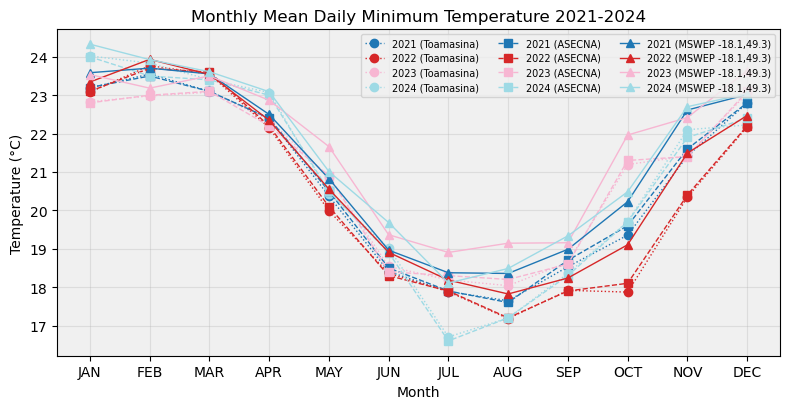

In [ ]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))

colors = plt.cm.tab20(np.linspace(0, 1, monthly_tmin_toamasina['year'].nunique()))
# Toamasina (numeric months 1-12)
for i, (year, row) in enumerate(monthly_tmin_toamasina.groupby('year')):
    ax.plot(row['month'], row['tmin'], color=colors[i], 
            linewidth=1, linestyle=':', marker='o', label=f'{year} (Toamasina)')  

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_minT_asecna.loc[2021:2024].iterrows()):
    ax.plot(np.arange(1, 13), row.values, color=colors[i], 
                linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_ERA_tmin_2021_2024.groupby('valid_time.year')):
    print(row["t2m"].values)
    ax.plot(np.arange(1, 13), row['t2m']-273.15, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Mean Daily Minimum Temperature 2021-2024')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmin_2021_2024_Toamasina_Asecna_ERA5-Land.png', dpi=300)
plt.show()


[301.274   300.5718  300.6097  298.39597 297.79776 295.68768 294.8214
 295.65286 296.23532 298.00558 299.91208 300.82355]
[300.0937  301.10605 299.93066 298.74695 297.4205  295.2166  294.47955
 295.52216 295.66498 297.62695 299.42188 300.22894]
[300.53625 300.10678 300.4955  299.7391  298.2941  296.70856 295.5258
 295.88092 297.10443 299.62872 299.50198 301.3186 ]
[301.05872 300.16595 299.9621  299.83313 297.27994 296.12332 296.4891
 296.21307 297.41052 298.18823 300.6491  301.18536]


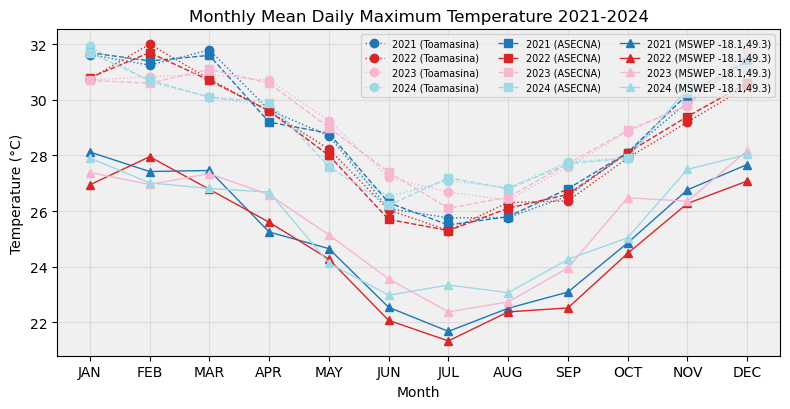

In [ ]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))

colors = plt.cm.tab20(np.linspace(0, 1, monthly_tmax_toamasina['year'].nunique()))
# Toamasina (numeric months 1-12)
for i, (year, row) in enumerate(monthly_tmax_toamasina.groupby('year')):
    ax.plot(row['month'], row['tmax'], color=colors[i], 
            linewidth=1, linestyle=':', marker='o', label=f'{year} (Toamasina)')  

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_maxT_asecna.loc[2021:2024].iterrows()):
    ax.plot(np.arange(1, 13), row.values, color=colors[i], 
                linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_ERA_tmax_2021_2024.groupby('valid_time.year')):
    print(row["t2m"].values)
    ax.plot(np.arange(1, 13), row['t2m']-273.15, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Mean Daily Maximum Temperature 2021-2024')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmax_2021_2024_Toamasina_Asecna_ERA5-Land.png', dpi=300)
plt.show()


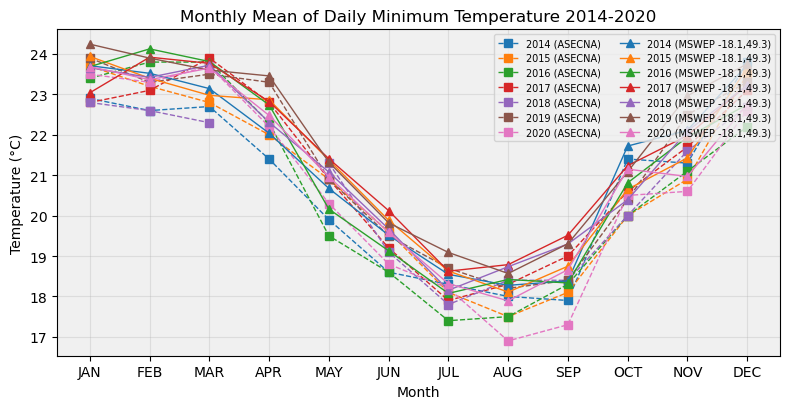

In [ ]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = plt.cm.tab20(np.linspace(0, 1, 11))

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_minT_asecna.loc[2014:2020].iterrows()):
    ax.plot(np.arange(1, 13), row.values, color=colors[i], 
            linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_ERA_tmin_2014_2020.groupby('valid_time.year')):
    months_numeric = row['valid_time.month'].values
    ax.plot(months_numeric, row['t2m']-273.15, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Mean of Daily Minimum Temperature 2014-2020')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmin_2014_2020_Asecna_ERA5-Land.png', dpi=300)
plt.show()


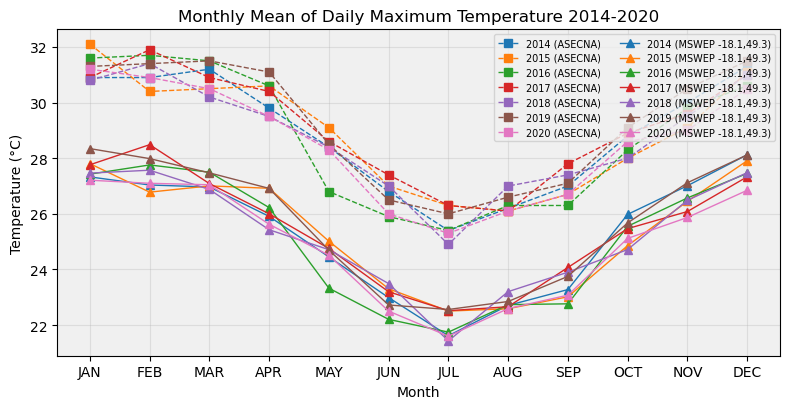

In [ ]:
month_map = {'JANV':1, 'FEV':2, 'MAR':3, 'AVR':4, 'MAI':5, 'JUIN':6,
             'JUIL':7, 'AOUT':8, 'SEPT':9, 'OCT':10, 'NOV':11, 'DEC':12}

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = plt.cm.tab20(np.linspace(0, 1, 11))

# ASECNA (convert to numeric months)
for i, (year, row) in enumerate(monthly_maxT_asecna.loc[2014:2020].iterrows()):
    ax.plot(np.arange(1, 13), row.values, color=colors[i], 
            linewidth=1, linestyle='--', marker='s', label=f'{year} (ASECNA)')

# Add MSWEP data
for i, (year, row) in enumerate(toamasina_ERA_tmax_2014_2020.groupby('valid_time.year')):
    months_numeric = row['valid_time.month'].values
    ax.plot(months_numeric, row['t2m']-273.15, color=colors[i], 
            linewidth=1, linestyle='-', marker='^', label=f'{year} (MSWEP {pos_toamasina[0]},{pos_toamasina[1]})')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
ax.set_title('Monthly Mean of Daily Maximum Temperature 2014-2020')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmax_2014_2020_Asecna_ERA5-Land.png', dpi=300)
plt.show()


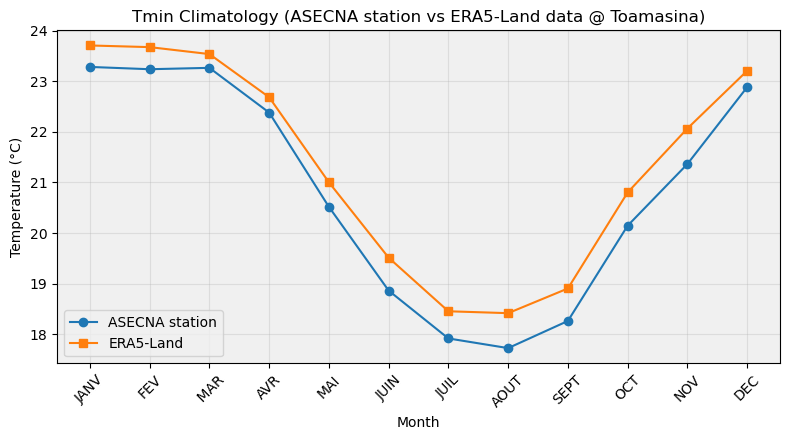

In [ ]:
# Plot monthly climatology
plt.figure(figsize=(8, 4.5))
plt.plot(climatology_minT_asecna.index, climatology_minT_asecna.values, marker='o', label='ASECNA station')
plt.plot(climatology_tmin_ERA['month']-1, climatology_tmin_ERA['t2m']-273.15, marker='s', label='ERA5-Land')
plt.title('Tmin Climatology (ASECNA station vs ERA5-Land data @ Toamasina)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='lower left', fontsize=10, ncol=1)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmin_climatology_2014_2024_ASECNA_ERA5-Land.png', dpi=300)#

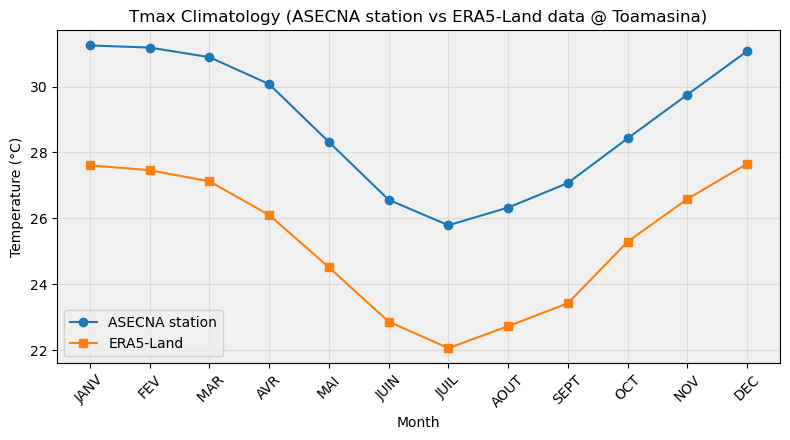

In [ ]:
# Plot monthly climatology
plt.figure(figsize=(8, 4.5))
plt.plot(climatology_maxT_asecna.index, climatology_maxT_asecna.values, marker='o', label='ASECNA station')
plt.plot(climatology_tmax_ERA['month']-1, climatology_tmax_ERA['t2m']-273.15, marker='s', label='ERA5-Land')
plt.title('Tmax Climatology (ASECNA station vs ERA5-Land data @ Toamasina)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='lower left', fontsize=10, ncol=1)
plt.tight_layout()
plt.savefig(figure_dir + 'monthly_tmax_climatology_2014_2024_ASECNA_ERA5-Land.png', dpi=300)#